# Demo Graphs — TFT Model Performance & Prediction Accuracy

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.style.use("dark_background")
plt.rcParams.update({
    "figure.figsize": (14, 5),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})

# Paths
METRICS_CSV  = "../lightning_logs/version_0/metrics.csv"
RAW_PARQUET  = "../model/tft/checkpoints/raw_data.parquet"
FEAT_PARQUET = "../model/tft/checkpoints/features.parquet"
CKPT_PATH    = "../model/tft/checkpoints/tft_model"

# Load training metrics (one row per logging step, sparse columns)
metrics = pl.read_csv(METRICS_CSV)
raw_data = pl.read_parquet(RAW_PARQUET)
features = pl.read_parquet(FEAT_PARQUET)

print(f"Training log: {metrics.shape[0]} rows, {metrics.shape[1]} cols")
print(f"Raw data:     {raw_data.shape[0]} rows, {raw_data['ticker'].n_unique()} tickers")
print(f"Features:     {features.shape[0]} rows")

Training log: 381 rows, 10 cols
Raw data:     2500 rows, 5 tickers
Features:     2500 rows


## 1 — Training Loss Curves

/var/folders/sb/jbh1d71j5c9clmnb_rnsjqb00000gn/T/ipykernel_39591/1537272899.py:40: DeprecationWarning: the argument `min_periods` for `Expr.rolling_mean` is deprecated. It was renamed to `min_samples` in version 1.21.0.
  pl.col("train_loss_step").rolling_mean(window_size=20, min_periods=1).alias("smooth")


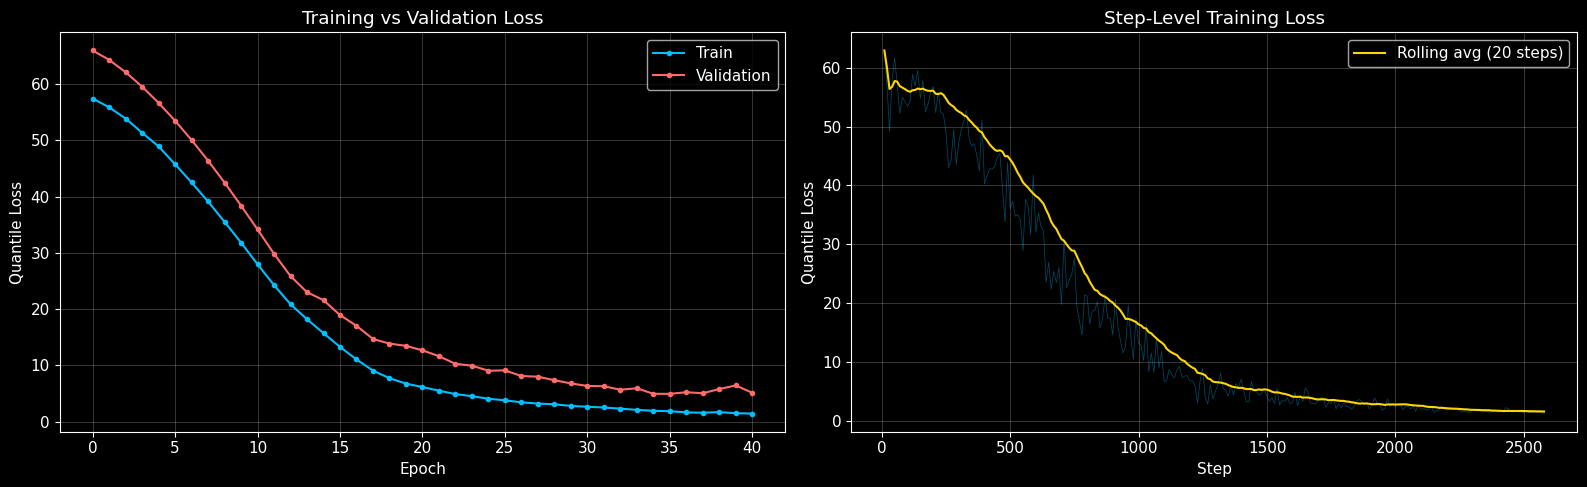

In [2]:
# --- 1a: Training vs Validation Loss by Epoch ---
# Training loss is logged per-step; validation loss per-epoch.
# Aggregate both to epoch level for an apples-to-apples comparison.

train_loss = (
    metrics
    .filter(pl.col("train_loss_epoch").is_not_null())
    .select("epoch", "train_loss_epoch")
    .rename({"train_loss_epoch": "loss"})
    .with_columns(pl.lit("Train").alias("split"))
)

val_loss = (
    metrics
    .filter(pl.col("val_loss").is_not_null())
    .select("epoch", "val_loss")
    .rename({"val_loss": "loss"})
    .with_columns(pl.lit("Validation").alias("split"))
)

loss_df = pl.concat([train_loss, val_loss]).sort("epoch")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: train vs val loss
for split, color in [("Train", "#00bfff"), ("Validation", "#ff6b6b")]:
    subset = loss_df.filter(pl.col("split") == split)
    axes[0].plot(subset["epoch"], subset["loss"], "o-", label=split, color=color, markersize=3, linewidth=1.5)

axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Quantile Loss")
axes[0].set_title("Training vs Validation Loss")
axes[0].legend()

# Right: step-level training loss (granular view)
step_loss = metrics.filter(pl.col("train_loss_step").is_not_null()).select("step", "train_loss_step")
axes[1].plot(step_loss["step"], step_loss["train_loss_step"], color="#00bfff", alpha=0.4, linewidth=0.5)
# Smoothed (rolling avg over 20 steps)
smoothed = step_loss.with_columns(
    pl.col("train_loss_step").rolling_mean(window_size=20, min_periods=1).alias("smooth")
)
axes[1].plot(smoothed["step"], smoothed["smooth"], color="#ffd700", linewidth=1.5, label="Rolling avg (20 steps)")
axes[1].set_xlabel("Step")
axes[1].set_ylabel("Quantile Loss")
axes[1].set_title("Step-Level Training Loss")
axes[1].legend()

plt.tight_layout()
plt.show()

## 2 — Validation Metrics Over Training (MAE, RMSE, SMAPE)

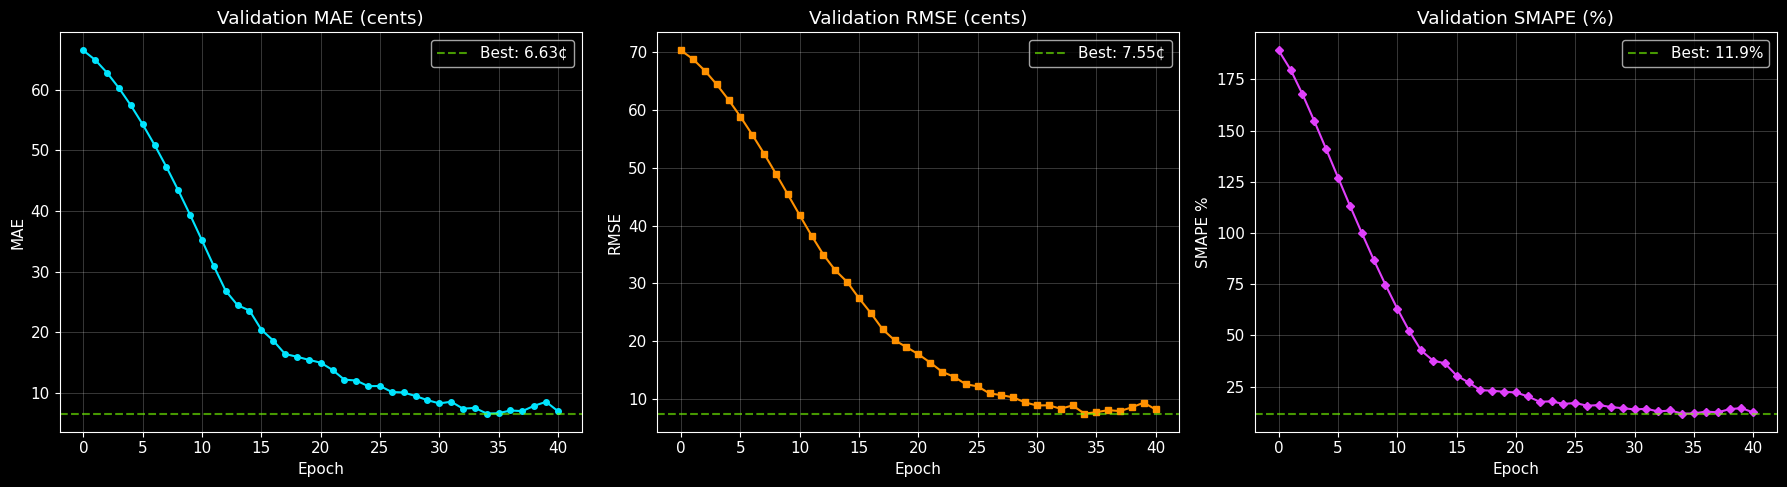


Final epoch metrics:
  MAE   = 7.03¢  (target price scale: 0-100¢)
  RMSE  = 8.26¢
  SMAPE = 12.4%
  MAPE  = 13.1%


In [3]:
# --- 2: Validation accuracy metrics over epochs ---
val_metrics = (
    metrics
    .filter(pl.col("val_MAE").is_not_null())
    .select("epoch", "val_MAE", "val_RMSE", "val_SMAPE", "val_MAPE")
    .sort("epoch")
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# MAE (cents) — lower is better
axes[0].plot(val_metrics["epoch"], val_metrics["val_MAE"], "o-", color="#00e5ff", markersize=4)
axes[0].set_title("Validation MAE (cents)")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MAE")
axes[0].axhline(y=val_metrics["val_MAE"].min(), color="#76ff03", linestyle="--", alpha=0.6,
                label=f"Best: {val_metrics['val_MAE'].min():.2f}¢")
axes[0].legend()

# RMSE (cents) — lower is better
axes[1].plot(val_metrics["epoch"], val_metrics["val_RMSE"], "s-", color="#ff9100", markersize=4)
axes[1].set_title("Validation RMSE (cents)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("RMSE")
axes[1].axhline(y=val_metrics["val_RMSE"].min(), color="#76ff03", linestyle="--", alpha=0.6,
                label=f"Best: {val_metrics['val_RMSE'].min():.2f}¢")
axes[1].legend()

# SMAPE (%) — lower is better
axes[2].plot(val_metrics["epoch"], val_metrics["val_SMAPE"] * 100, "D-", color="#e040fb", markersize=4)
axes[2].set_title("Validation SMAPE (%)")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("SMAPE %")
axes[2].axhline(y=val_metrics["val_SMAPE"].min() * 100, color="#76ff03", linestyle="--", alpha=0.6,
                label=f"Best: {val_metrics['val_SMAPE'].min() * 100:.1f}%")
axes[2].legend()

plt.tight_layout()
plt.show()

# Print final metrics
last = val_metrics.tail(1)
print(f"\nFinal epoch metrics:")
print(f"  MAE   = {last['val_MAE'][0]:.2f}¢  (target price scale: 0-100¢)")
print(f"  RMSE  = {last['val_RMSE'][0]:.2f}¢")
print(f"  SMAPE = {last['val_SMAPE'][0]*100:.1f}%")
print(f"  MAPE  = {last['val_MAPE'][0]*100:.1f}%")

## 3 — TFT Predictions vs Actual Prices

In [4]:
# --- 3: Load trained TFT and run predictions on the full feature set ---
import torch
from model.tft.tft_model import TFTPredictor

predictor = TFTPredictor.load(CKPT_PATH)
predictions = predictor.predict(features)

print(f"Generated {len(predictions)} ticker-level predictions:")
for p in predictions:
    print(f"  {p.ticker}: predicted={p.predicted_price:.1f}¢, actual={p.current_price:.1f}¢, "
          f"deviation={p.deviation:+.1f}¢, uncertainty={p.uncertainty:.1f}¢, "
          f"confidence={p.confidence:.2f}")

/Users/heywood/Library/CloudStorage/OneDrive-Williams-Tracy/kalshi_v5/.venv/lib/python3.14/site-packages/pytorch_forecasting/models/base/_base_model.py:30: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm
/Users/heywood/Library/CloudStorage/OneDrive-Williams-Tracy/kalshi_v5/.venv/lib/python3.14/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
/Users/heywood/Library/CloudStorage/OneDrive-Williams-Tracy/kalshi_v5/.venv/lib/python3.14/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.

Generated 5 ticker-level predictions:
  KXBTCD-26APR1817: predicted=57.3¢, actual=41.9¢, deviation=+15.4¢, uncertainty=7.7¢, confidence=2.00
  KXBTCD-26APR1818: predicted=97.7¢, actual=87.9¢, deviation=+9.8¢, uncertainty=7.6¢, confidence=1.30
  KXBTCD-26APR1819: predicted=51.8¢, actual=56.0¢, deviation=-4.2¢, uncertainty=6.5¢, confidence=0.64
  KXBTCD-26APR1820: predicted=46.4¢, actual=53.4¢, deviation=-7.0¢, uncertainty=6.0¢, confidence=1.16
  KXBTCD-26APR1821: predicted=96.5¢, actual=99.0¢, deviation=-2.5¢, uncertainty=8.2¢, confidence=0.31


/Users/heywood/Library/CloudStorage/OneDrive-Williams-Tracy/kalshi_v5/.venv/lib/python3.14/site-packages/pytorch_forecasting/data/timeseries/_timeseries.py:1942: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_numpy.cpp:219.)
  self.data["groups"][index_start].numpy(), columns=self.group_ids


In [5]:
# --- 3a: Run predictions over the full feature set and get per-sample results ---
from pytorch_forecasting import TimeSeriesDataSet

pdf = features.to_pandas()
pdf["time_idx"] = pdf["time_idx"].astype(int)
pdf["ticker"] = pdf["ticker"].astype(str)

# Build prediction dataset from the training dataset template
pred_ds = TimeSeriesDataSet.from_dataset(
    predictor._training_dataset, pdf, predict=True, stop_randomization=True
)
pred_dl = pred_ds.to_dataloader(train=False, batch_size=128, num_workers=0)

# Run model inference — get raw quantile predictions
raw_preds = predictor.model.predict(pred_dl, mode="raw")
pred_tensor = raw_preds.prediction  # (n_samples, prediction_length, n_quantiles)

# Map predictions back to tickers and time indices
decoded = pred_ds.decoded_index
print(f"Decoded index columns: {list(decoded.columns)}")
print(f"Prediction tensor shape: {pred_tensor.shape}")
print(f"Decoded index rows: {len(decoded)}")

# Build results — for each sample, get predictions at each forecast step
pred_len = predictor.prediction_length
results = []

for i in range(min(len(decoded), pred_tensor.shape[0])):
    row = decoded.iloc[i]
    tk = str(row["ticker"])
    first_pred_idx = int(row["time_idx_first_prediction"])

    # Extract predictions at each forecast horizon
    for step in range(pred_len):
        target_idx = first_pred_idx + step
        q10 = float(pred_tensor[i, step, 0].clamp(0, 100))
        q50 = float(pred_tensor[i, step, 1].clamp(0, 100))
        q90 = float(pred_tensor[i, step, 2].clamp(0, 100))

        # Find the actual yes_price at this time step
        actual_row = features.filter(
            (pl.col("ticker") == tk) & (pl.col("time_idx") == target_idx)
        )
        if actual_row.height == 0:
            continue
        actual = float(actual_row["yes_price"][0])
        results.append((tk, target_idx, actual, q50, q10, q90, step + 1))

pred_df = pl.DataFrame(
    results,
    schema={"ticker": pl.Utf8, "time_idx": pl.Int64, "actual": pl.Float64,
            "predicted": pl.Float64, "lower": pl.Float64, "upper": pl.Float64,
            "horizon": pl.Int64},
    orient="row",
)
pred_df = pred_df.with_columns(
    (pl.col("predicted") - pl.col("actual")).alias("error"),
    (pl.col("predicted") - pl.col("actual")).abs().alias("abs_error"),
)

print(f"\nPredictions: {pred_df.shape[0]} points across {pred_df['ticker'].n_unique()} tickers")
if pred_df.height > 0:
    print(f"Overall MAE:  {pred_df['abs_error'].mean():.2f}¢")
    print(f"Overall RMSE: {(pred_df['error'].pow(2).mean() ** 0.5):.2f}¢")
    # Per-horizon MAE
    print("\nMAE by forecast horizon:")
    for h in range(1, pred_len + 1):
        h_df = pred_df.filter(pl.col("horizon") == h)
        if h_df.height > 0:
            print(f"  h={h}: MAE={h_df['abs_error'].mean():.2f}¢  ({h_df.height} samples)")
else:
    print("WARNING: No prediction-actual pairs matched.")

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
/Users/heywood/Library/CloudStorage/OneDrive-Williams-Tracy/kalshi_v5/.venv/lib/python3.14/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/Users/heywood/Library/CloudStorage/OneDrive-Williams-Tracy/kalshi_v5/.venv/lib/python3.14/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'predict_dataloader' does not have many workers whic

Decoded index columns: ['ticker', 'time_idx_first', 'time_idx_last', 'time_idx_first_prediction']
Prediction tensor shape: torch.Size([5, 10, 3])
Decoded index rows: 5

Predictions: 50 points across 5 tickers
Overall MAE:  7.03¢
Overall RMSE: 8.26¢

MAE by forecast horizon:
  h=1: MAE=5.32¢  (5 samples)
  h=2: MAE=6.39¢  (5 samples)
  h=3: MAE=5.98¢  (5 samples)
  h=4: MAE=6.75¢  (5 samples)
  h=5: MAE=7.35¢  (5 samples)
  h=6: MAE=7.66¢  (5 samples)
  h=7: MAE=7.96¢  (5 samples)
  h=8: MAE=7.30¢  (5 samples)
  h=9: MAE=7.80¢  (5 samples)
  h=10: MAE=7.77¢  (5 samples)


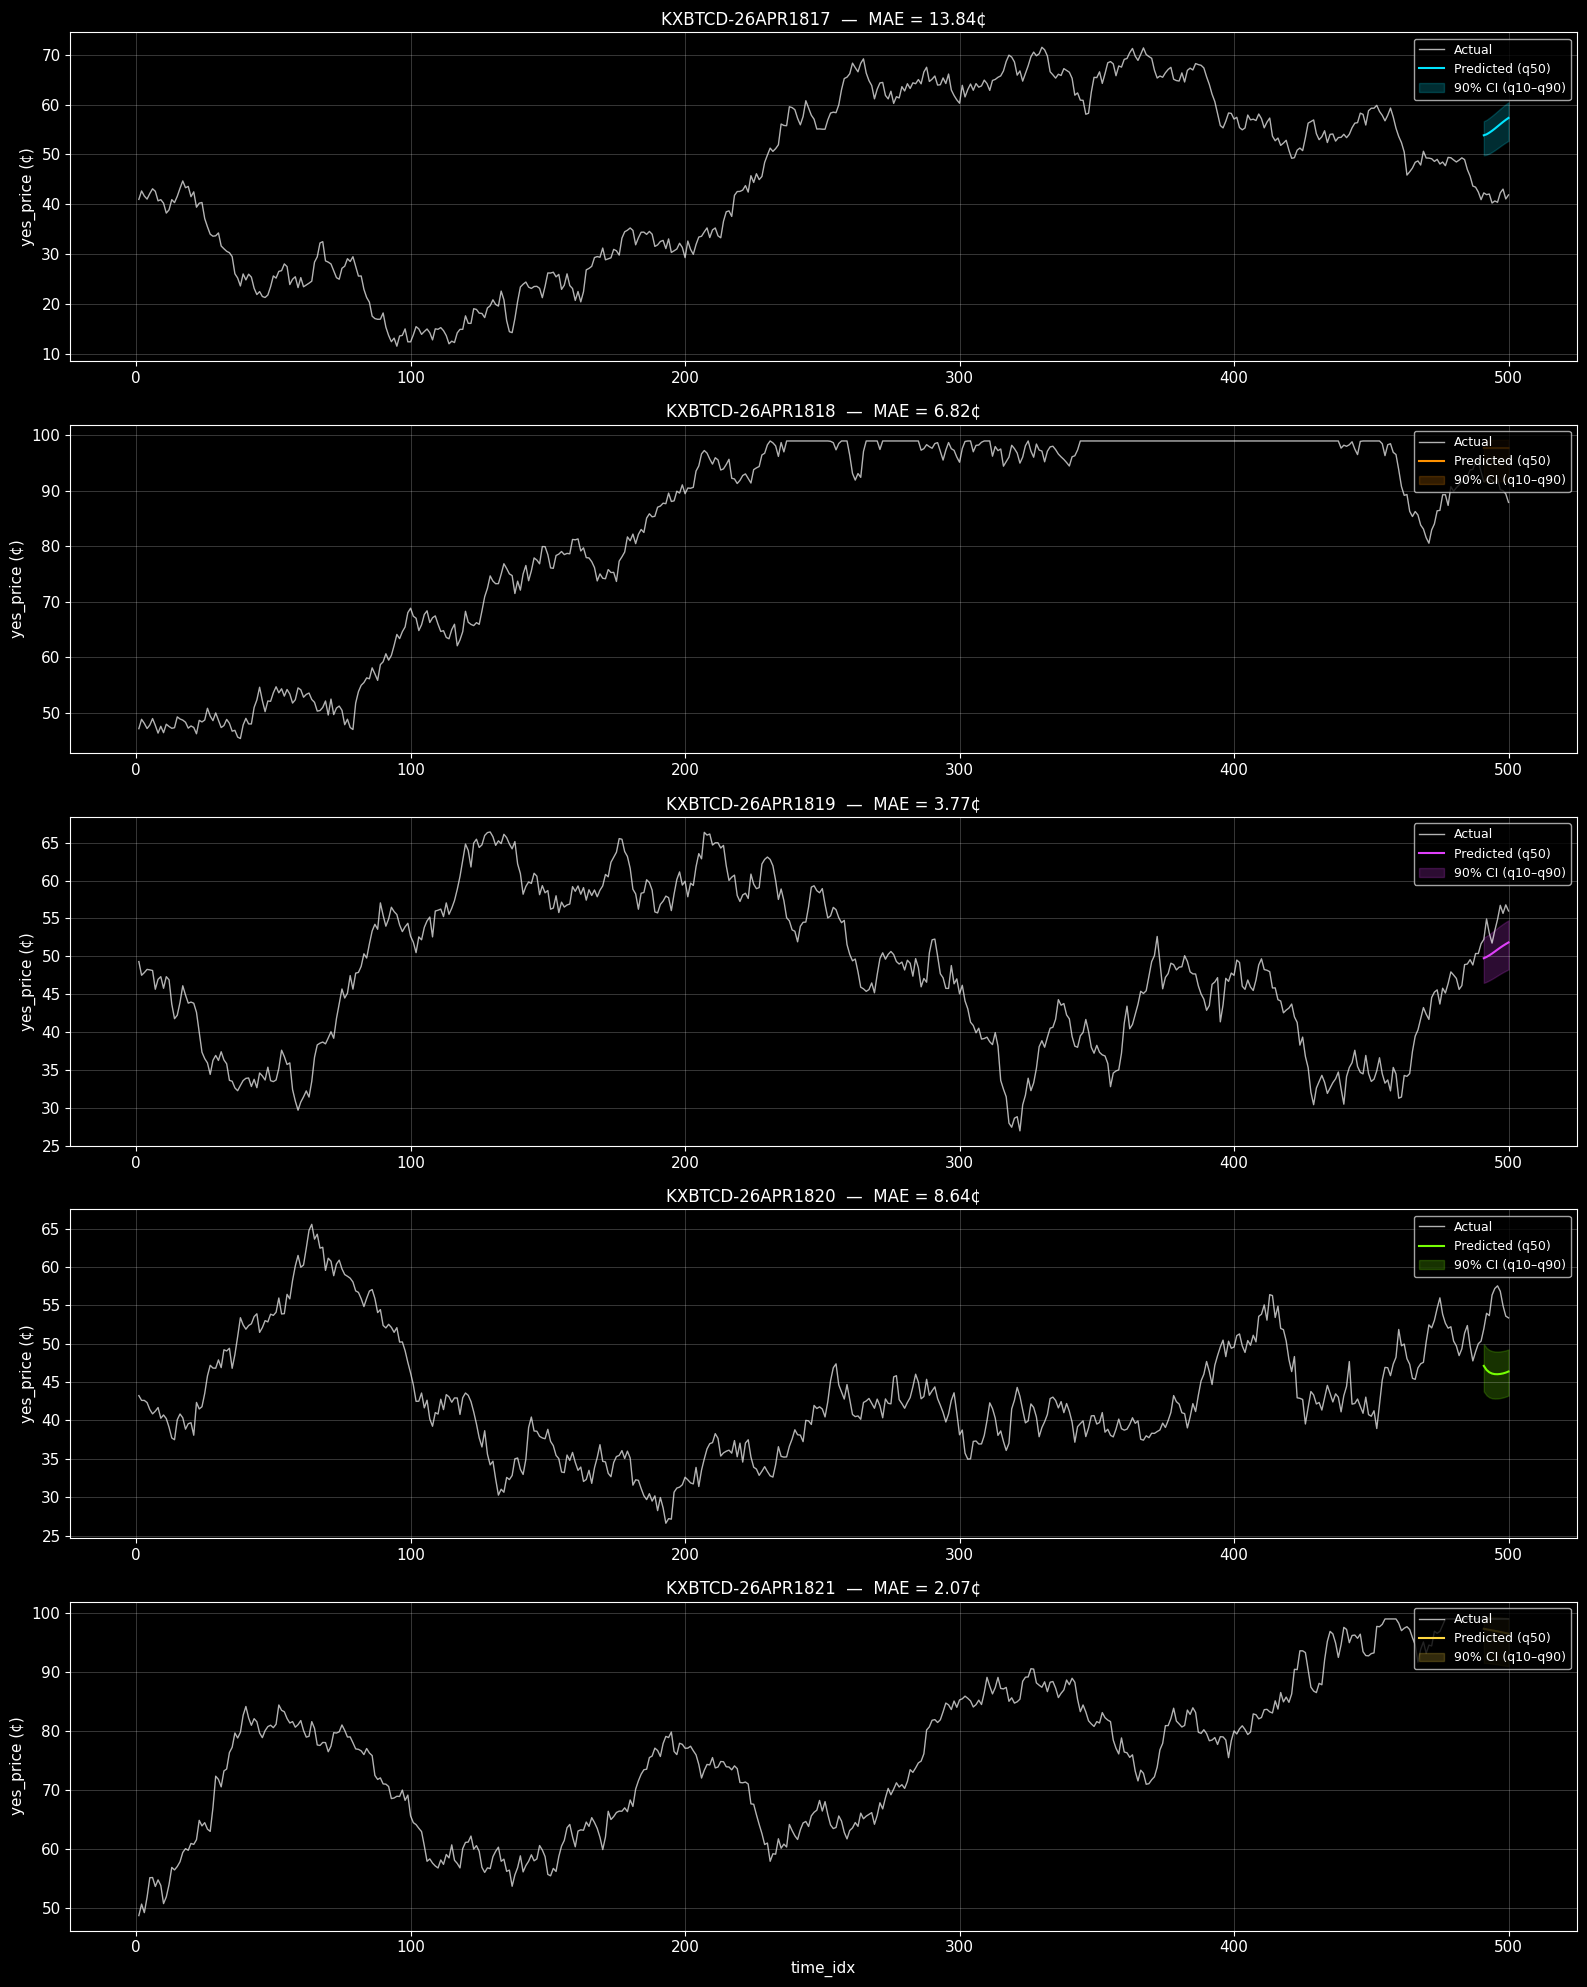

In [6]:
# --- 3b: Predicted vs Actual time series per ticker (with uncertainty bands) ---
if pred_df.height == 0:
    print("No predictions to plot — skipping time series chart.")
else:
    n_tickers = pred_df["ticker"].n_unique()
    fig, axes = plt.subplots(max(n_tickers, 1), 1, figsize=(16, 4 * max(n_tickers, 1)), sharex=False)
    if n_tickers == 1:
        axes = [axes]

    colors = ["#00e5ff", "#ff9100", "#e040fb", "#76ff03", "#ffd740"]

    for i, tk in enumerate(sorted(pred_df["ticker"].unique().to_list())):
        ax = axes[i]
        tk_pred = pred_df.filter(pl.col("ticker") == tk).sort("time_idx")
        tk_feat = features.filter(pl.col("ticker") == tk).sort("time_idx")

        # Full actual price series
        ax.plot(tk_feat["time_idx"], tk_feat["yes_price"],
                color="white", linewidth=1, alpha=0.7, label="Actual")

        # Predicted median
        ax.plot(tk_pred["time_idx"], tk_pred["predicted"],
                color=colors[i % len(colors)], linewidth=1.5, label="Predicted (q50)")

        # Uncertainty band (q10-q90)
        ax.fill_between(
            tk_pred["time_idx"].to_list(),
            tk_pred["lower"].to_list(),
            tk_pred["upper"].to_list(),
            alpha=0.2, color=colors[i % len(colors)], label="90% CI (q10–q90)"
        )

        mae = tk_pred["abs_error"].mean()
        ax.set_title(f"{tk}  —  MAE = {mae:.2f}¢", fontsize=12)
        ax.set_ylabel("yes_price (¢)")
        ax.legend(loc="upper right", fontsize=9)

    axes[-1].set_xlabel("time_idx")
    plt.tight_layout()
    plt.show()

## 4 — Prediction Error Analysis

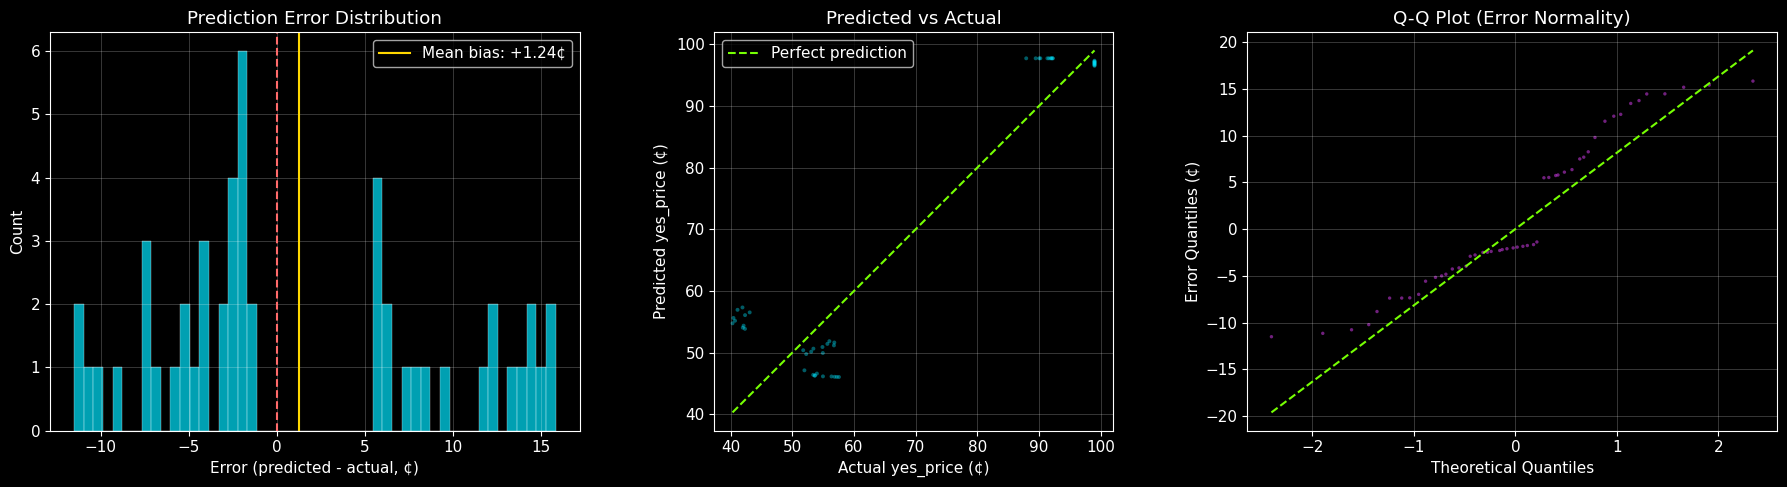

In [7]:
# --- 4a: Error distribution and scatter ---
if pred_df.height == 0:
    print("No predictions — skipping error analysis.")
else:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    errors = pred_df["error"].to_numpy()

    # Histogram of prediction errors
    axes[0].hist(errors, bins=50, color="#00e5ff", alpha=0.7, edgecolor="white", linewidth=0.3)
    axes[0].axvline(x=0, color="#ff6b6b", linestyle="--", linewidth=1.5)
    axes[0].axvline(x=np.mean(errors), color="#ffd700", linestyle="-", linewidth=1.5,
                    label=f"Mean bias: {np.mean(errors):+.2f}¢")
    axes[0].set_title("Prediction Error Distribution")
    axes[0].set_xlabel("Error (predicted - actual, ¢)")
    axes[0].set_ylabel("Count")
    axes[0].legend()

    # Scatter: predicted vs actual (all tickers)
    axes[1].scatter(pred_df["actual"], pred_df["predicted"],
                    s=8, alpha=0.4, c="#00e5ff", edgecolors="none")
    lo = min(pred_df["actual"].min(), pred_df["predicted"].min())
    hi = max(pred_df["actual"].max(), pred_df["predicted"].max())
    axes[1].plot([lo, hi], [lo, hi], "--", color="#76ff03", linewidth=1.5, label="Perfect prediction")
    axes[1].set_title("Predicted vs Actual")
    axes[1].set_xlabel("Actual yes_price (¢)")
    axes[1].set_ylabel("Predicted yes_price (¢)")
    axes[1].set_aspect("equal")
    axes[1].legend()

    # QQ-plot of errors (normality check)
    sorted_err = np.sort(errors)
    n = len(sorted_err)
    theoretical_q = np.array([
        np.percentile(np.random.standard_normal(10000), 100 * (i + 0.5) / n)
        for i in range(n)
    ])
    axes[2].scatter(theoretical_q, sorted_err, s=6, alpha=0.5, c="#e040fb", edgecolors="none")
    axes[2].plot([theoretical_q.min(), theoretical_q.max()],
                 [theoretical_q.min() * np.std(errors), theoretical_q.max() * np.std(errors)],
                 "--", color="#76ff03", linewidth=1.5)
    axes[2].set_title("Q-Q Plot (Error Normality)")
    axes[2].set_xlabel("Theoretical Quantiles")
    axes[2].set_ylabel("Error Quantiles (¢)")

    plt.tight_layout()
    plt.show()

/var/folders/sb/jbh1d71j5c9clmnb_rnsjqb00000gn/T/ipykernel_39591/1015453330.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot(error_groups, labels=short_labels, patch_artist=True,


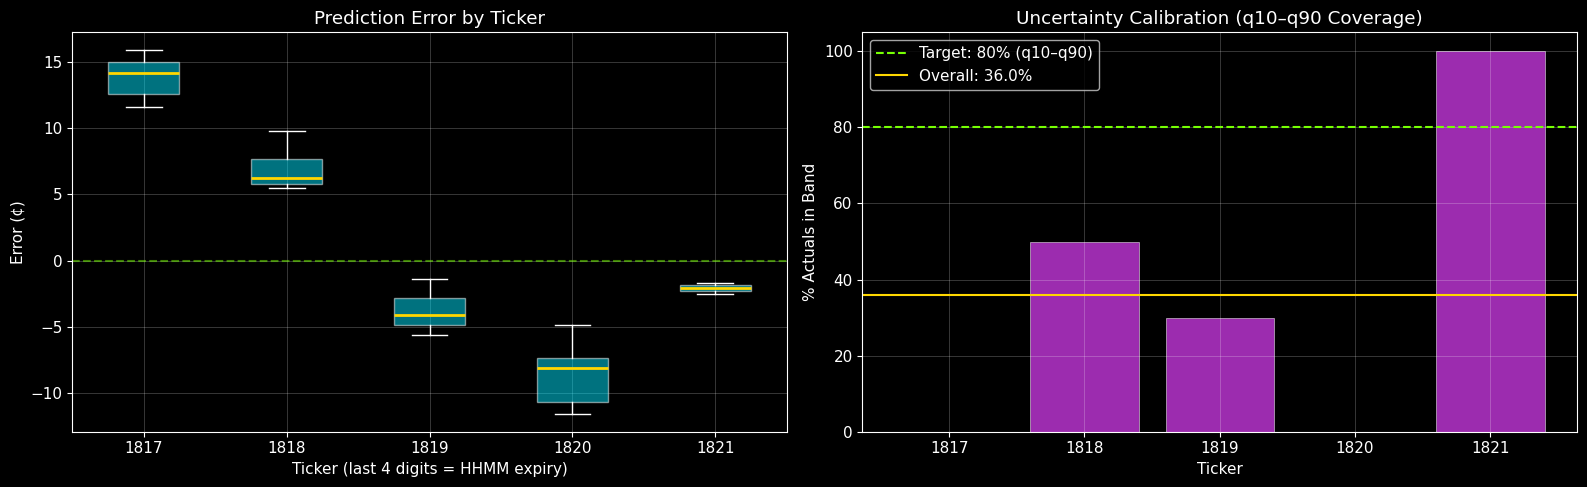

In [8]:
# --- 4b: Per-ticker error boxplot + calibration of uncertainty bands ---
if pred_df.height == 0:
    print("No predictions — skipping per-ticker analysis.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    ticker_list = sorted(pred_df["ticker"].unique().to_list())
    error_groups = [pred_df.filter(pl.col("ticker") == tk)["error"].to_numpy() for tk in ticker_list]
    short_labels = [tk.replace("KXBTCD-26APR", "") for tk in ticker_list]

    bp = axes[0].boxplot(error_groups, labels=short_labels, patch_artist=True,
                         boxprops=dict(facecolor="#00e5ff", alpha=0.5),
                         medianprops=dict(color="#ffd700", linewidth=2),
                         whiskerprops=dict(color="white"),
                         capprops=dict(color="white"),
                         flierprops=dict(marker=".", markerfacecolor="#ff6b6b", markersize=3))
    axes[0].axhline(y=0, color="#76ff03", linestyle="--", alpha=0.5)
    axes[0].set_title("Prediction Error by Ticker")
    axes[0].set_xlabel("Ticker (last 4 digits = HHMM expiry)")
    axes[0].set_ylabel("Error (¢)")

    # Calibration: what fraction of actuals fall inside the [q10, q90] band?
    in_band = pred_df.filter(
        (pl.col("actual") >= pl.col("lower")) & (pl.col("actual") <= pl.col("upper"))
    )
    overall_coverage = in_band.height / max(pred_df.height, 1)

    per_ticker_coverage = []
    for tk in ticker_list:
        tk_d = pred_df.filter(pl.col("ticker") == tk)
        tk_in = tk_d.filter((pl.col("actual") >= pl.col("lower")) & (pl.col("actual") <= pl.col("upper")))
        cov = tk_in.height / max(tk_d.height, 1)
        per_ticker_coverage.append(cov)

    bars = axes[1].bar(short_labels, [c * 100 for c in per_ticker_coverage],
                       color="#e040fb", alpha=0.7, edgecolor="white", linewidth=0.5)
    axes[1].axhline(y=80, color="#76ff03", linestyle="--", linewidth=1.5,
                    label="Target: 80% (q10–q90)")
    axes[1].axhline(y=overall_coverage * 100, color="#ffd700", linestyle="-", linewidth=1.5,
                    label=f"Overall: {overall_coverage*100:.1f}%")
    axes[1].set_title("Uncertainty Calibration (q10–q90 Coverage)")
    axes[1].set_xlabel("Ticker")
    axes[1].set_ylabel("% Actuals in Band")
    axes[1].set_ylim(0, 105)
    axes[1].legend()

    plt.tight_layout()
    plt.show()

## 5 — Trading Signal Analysis (Edge & Expected Value)

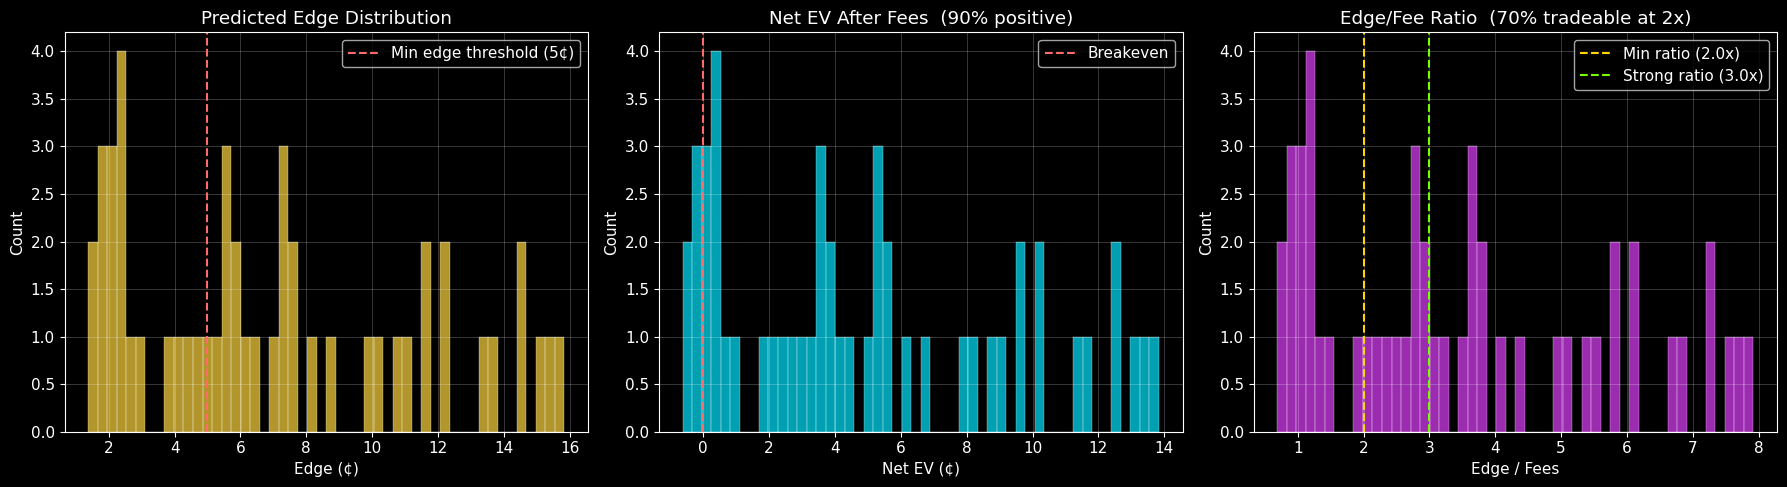

In [9]:
# --- 5: Simulate trading signals from predictions ---
if pred_df.height == 0:
    print("No predictions — skipping signal analysis.")
else:
    from model.tft.tft_model import TFTPrediction

    signal_rows = []
    for row in pred_df.iter_rows(named=True):
        pred_obj = TFTPrediction(
            ticker=row["ticker"],
            predicted_price=row["predicted"],
            lower_bound=row["lower"],
            upper_bound=row["upper"],
            uncertainty=row["upper"] - row["lower"],
            current_price=row["actual"],
        )
        edge = abs(pred_obj.deviation)
        direction = pred_obj.direction
        net_ev = pred_obj.net_ev(contracts=1, maker=True)
        efr = pred_obj.edge_fee_ratio(contracts=1, maker=True)
        signal_rows.append({
            "ticker": row["ticker"],
            "time_idx": row["time_idx"],
            "edge": edge,
            "direction": direction,
            "net_ev": net_ev,
            "edge_fee_ratio": efr,
            "confidence": pred_obj.confidence,
        })

    signals = pl.DataFrame(signal_rows)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Edge distribution
    axes[0].hist(signals["edge"].to_numpy(), bins=50, color="#ffd740", alpha=0.7,
                 edgecolor="white", linewidth=0.3)
    axes[0].axvline(x=5, color="#ff6b6b", linestyle="--", linewidth=1.5,
                    label="Min edge threshold (5¢)")
    axes[0].set_title("Predicted Edge Distribution")
    axes[0].set_xlabel("Edge (¢)")
    axes[0].set_ylabel("Count")
    axes[0].legend()

    # Net EV distribution
    axes[1].hist(signals["net_ev"].to_numpy(), bins=50, color="#00e5ff", alpha=0.7,
                 edgecolor="white", linewidth=0.3)
    axes[1].axvline(x=0, color="#ff6b6b", linestyle="--", linewidth=1.5, label="Breakeven")
    pct_positive = (signals.filter(pl.col("net_ev") > 0).height / max(signals.height, 1)) * 100
    axes[1].set_title(f"Net EV After Fees  ({pct_positive:.0f}% positive)")
    axes[1].set_xlabel("Net EV (¢)")
    axes[1].set_ylabel("Count")
    axes[1].legend()

    # Edge-fee ratio distribution
    efr_vals = signals["edge_fee_ratio"].to_numpy()
    efr_clipped = np.clip(efr_vals, 0, 20)
    axes[2].hist(efr_clipped, bins=50, color="#e040fb", alpha=0.7,
                 edgecolor="white", linewidth=0.3)
    axes[2].axvline(x=2.0, color="#ffd700", linestyle="--", linewidth=1.5, label="Min ratio (2.0x)")
    axes[2].axvline(x=3.0, color="#76ff03", linestyle="--", linewidth=1.5, label="Strong ratio (3.0x)")
    pct_tradeable = (signals.filter(pl.col("edge_fee_ratio") >= 2.0).height / max(signals.height, 1)) * 100
    axes[2].set_title(f"Edge/Fee Ratio  ({pct_tradeable:.0f}% tradeable at 2x)")
    axes[2].set_xlabel("Edge / Fees")
    axes[2].set_ylabel("Count")
    axes[2].legend()

    plt.tight_layout()
    plt.show()

## 6 — Feature Importance & Input Data Overview

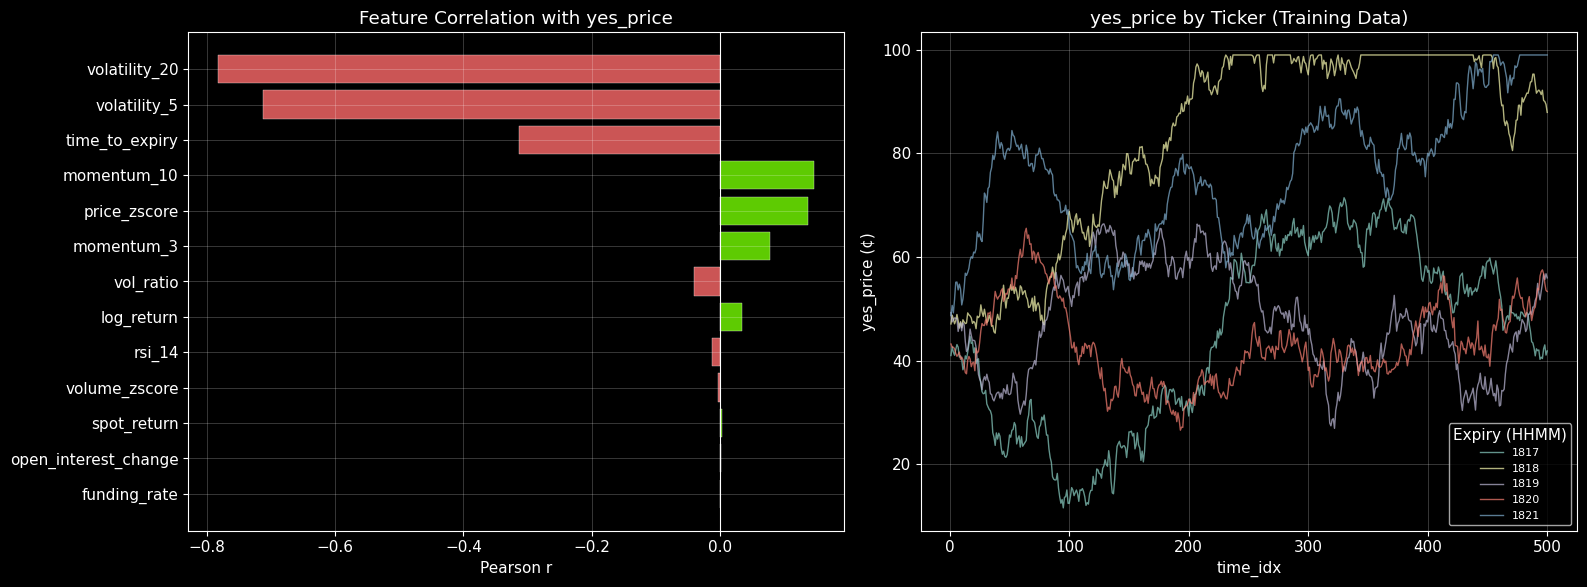

In [10]:
# --- 6a: Feature correlation with target (yes_price) ---
feature_cols = [
    "log_return", "volatility_5", "volatility_20", "vol_ratio",
    "momentum_3", "momentum_10", "rsi_14", "price_zscore",
    "spot_return", "funding_rate", "volume_zscore", "open_interest_change",
    "time_to_expiry",
]

# Compute Pearson correlation of each feature with yes_price
correlations = {}
for col in feature_cols:
    corr = features.select(pl.corr("yes_price", col)).item()
    correlations[col] = corr if corr is not None else 0.0

# Sort by absolute correlation
sorted_feats = sorted(correlations.items(), key=lambda x: abs(x[1]), reverse=True)
feat_names = [f[0] for f in sorted_feats]
feat_corrs = [f[1] for f in sorted_feats]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Horizontal bar chart of correlations
colors_bar = ["#76ff03" if c > 0 else "#ff6b6b" for c in feat_corrs]
axes[0].barh(feat_names[::-1], feat_corrs[::-1], color=colors_bar[::-1], alpha=0.8, edgecolor="white", linewidth=0.3)
axes[0].axvline(x=0, color="white", linewidth=0.8)
axes[0].set_title("Feature Correlation with yes_price")
axes[0].set_xlabel("Pearson r")

# Price time series overview (all tickers, overlay)
for tk in sorted(features["ticker"].unique().to_list()):
    tk_d = features.filter(pl.col("ticker") == tk).sort("time_idx")
    axes[1].plot(tk_d["time_idx"], tk_d["yes_price"], linewidth=1, alpha=0.7,
                 label=tk.replace("KXBTCD-26APR", ""))
axes[1].set_title("yes_price by Ticker (Training Data)")
axes[1].set_xlabel("time_idx")
axes[1].set_ylabel("yes_price (¢)")
axes[1].legend(title="Expiry (HHMM)", fontsize=8)

plt.tight_layout()
plt.show()